In [1]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, roc_curve, auc)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
import matplotlib.pyplot as plt
import seaborn as sns

# Data Analysis

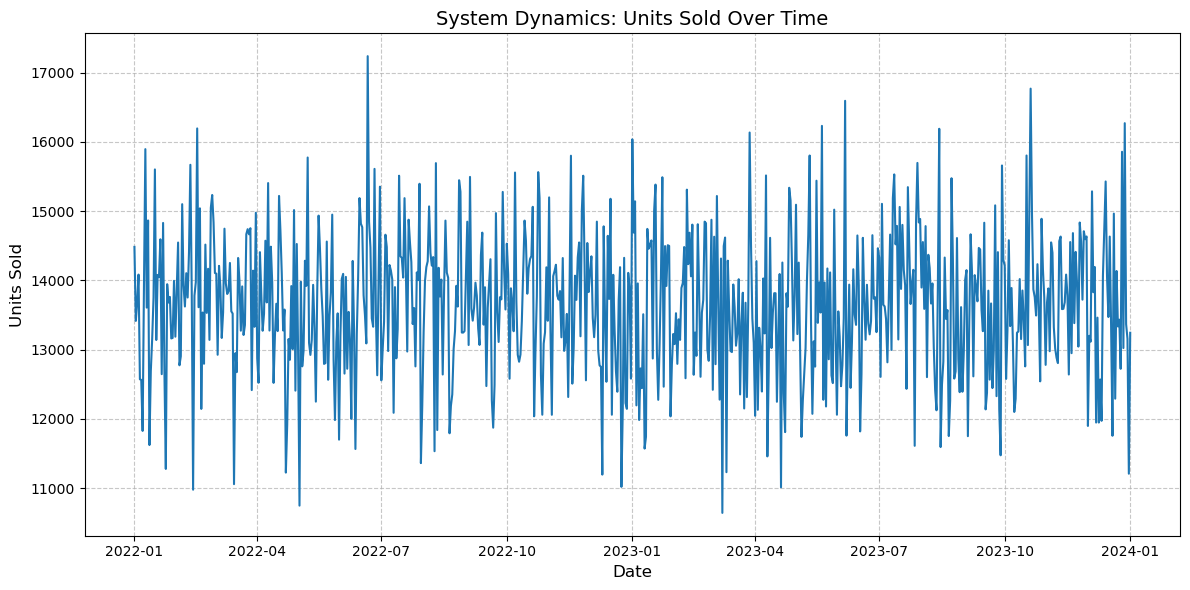

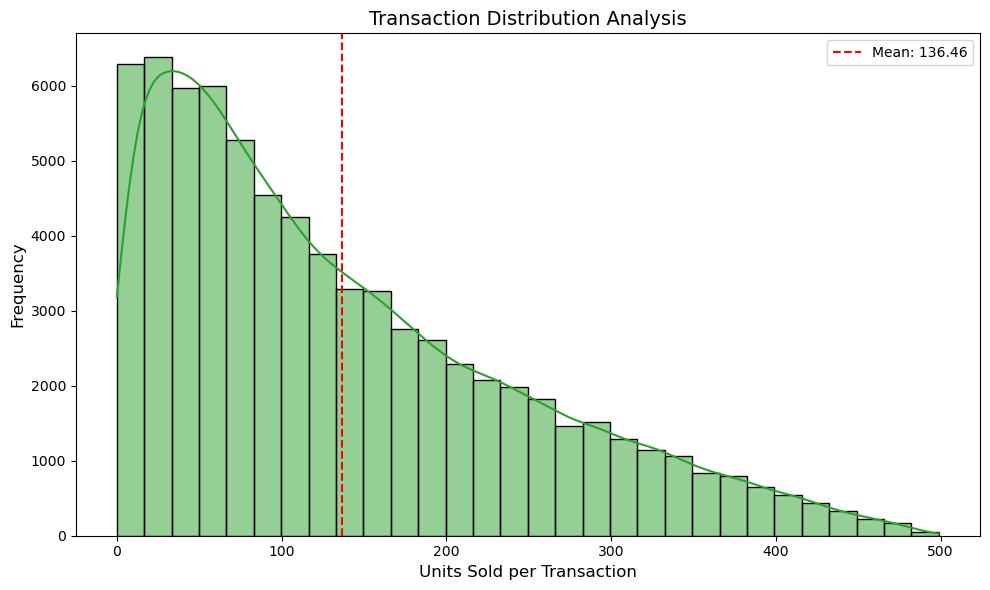

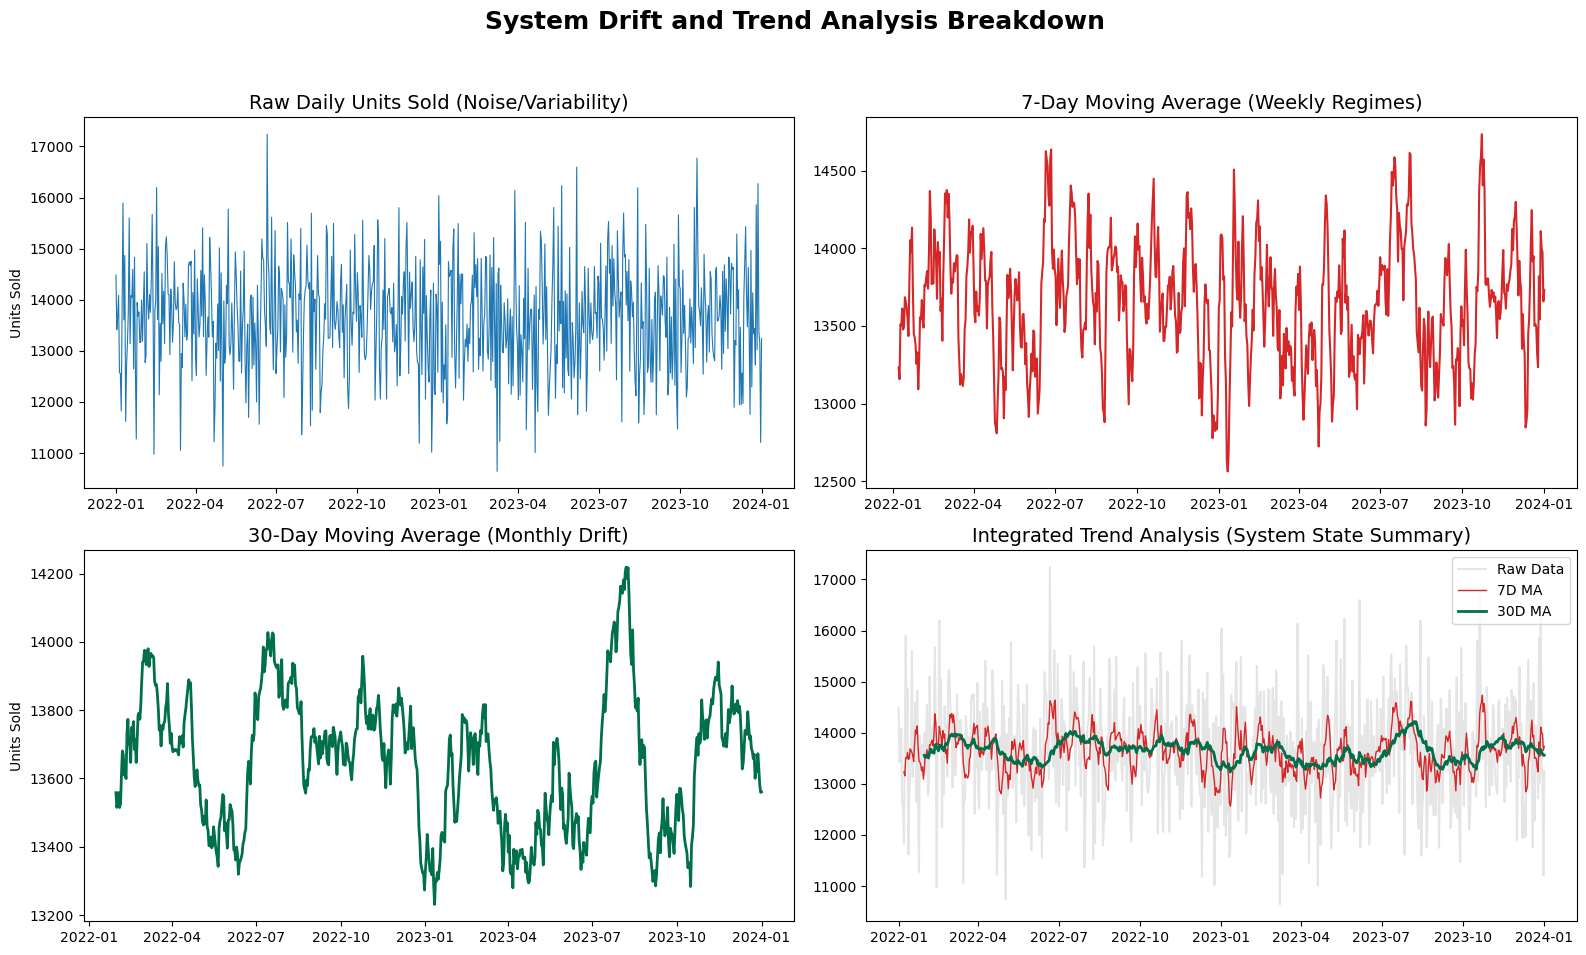

In [2]:
# Load the data
df = pd.read_csv('retail_store_inventory.csv')
df['Date'] = pd.to_datetime(df['Date'])

# 1. Time Series Analysis Plot
# Aggregating Units Sold by Date to see the system flow
time_series = df.groupby('Date')['Units Sold'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(time_series['Date'], time_series['Units Sold'], color='#1e77b4', linewidth=1.5)
plt.title('System Dynamics: Units Sold Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Units Sold', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. Distribution Analysis Plot
# Showing the density and frequency of Units Sold
plt.figure(figsize=(10, 6))
sns.histplot(df['Units Sold'], kde=True, color='#2ca02c', bins=30)
plt.title('Transaction Distribution Analysis', fontsize=14)
plt.xlabel('Units Sold per Transaction', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(df['Units Sold'].mean(), color='red', linestyle='--', label=f'Mean: {df["Units Sold"].mean():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

daily_ts = df.groupby('Date')['Units Sold'].sum().reset_index().set_index('Date')


daily_ts['7D_MA'] = daily_ts['Units Sold'].rolling(window=7).mean()
daily_ts['30D_MA'] = daily_ts['Units Sold'].rolling(window=30).mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('System Drift and Trend Analysis Breakdown', fontsize=18, fontweight='bold')

# --- Plot 1: Raw Daily Data ---
axes[0, 0].plot(daily_ts.index, daily_ts['Units Sold'], color='#1f77b4', linewidth=0.8)
axes[0, 0].set_title('Raw Daily Units Sold (Noise/Variability)', fontsize=14)
axes[0, 0].set_ylabel('Units Sold')

# --- Plot 2: 7-Day Moving Average ---
axes[0, 1].plot(daily_ts.index, daily_ts['7D_MA'], color='#d62728', linewidth=1.5)
axes[0, 1].set_title('7-Day Moving Average (Weekly Regimes)', fontsize=14)

# --- Plot 3: 30-Day Moving Average ---
axes[1, 0].plot(daily_ts.index, daily_ts['30D_MA'], color='#00704A', linewidth=2)
axes[1, 0].set_title('30-Day Moving Average (Monthly Drift)', fontsize=14)
axes[1, 0].set_ylabel('Units Sold')

# --- Plot 4: Combined Trend Analysis  ---
axes[1, 1].plot(daily_ts.index, daily_ts['Units Sold'], alpha=0.2, color='gray', label='Raw Data')
axes[1, 1].plot(daily_ts.index, daily_ts['7D_MA'], color='#d62728', label='7D MA', linewidth=1)
axes[1, 1].plot(daily_ts.index, daily_ts['30D_MA'], color='#00704A', label='30D MA', linewidth=2)
axes[1, 1].set_title('Integrated Trend Analysis (System State Summary)', fontsize=14)
axes[1, 1].legend(loc='upper right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Data Pre-processing, Feature Engineering, CV, Model Development

In [3]:
# ---------------------------------------------------------
# 1. Load Data & Feature Engineering
# ---------------------------------------------------------
df = pd.read_csv("raw_data.csv")
df["Date_parsed"] = pd.to_datetime(df["Date"])

# Sort by Store -> Item -> Date to calculate the 7-day rolling forecast accurately
df = df.sort_values(["Store ID", "item_id", "Date_parsed"]).reset_index(drop=True)

def forward_sum_next_k(arr: np.ndarray, k: int = 7) -> np.ndarray:
    out = np.zeros_like(arr, dtype=float)
    n = len(arr)
    for i in range(n):
        out[i] = arr[i+1:i+1+k].sum() if i + 1 < n else 0.0
    return out

# Rolling 7-day forecast
df["forecast_next_7d"] = df.groupby(["Store ID", "item_id"])["Demand Forecast"].transform(lambda s: forward_sum_next_k(s.to_numpy(), k=7))
df["dayofweek"] = df["Date_parsed"].dt.dayofweek
df["month"] = df["Date_parsed"].dt.month

# ---------------------------------------------------------
# 2. CRITICAL: Re-sort strictly by Date for Time Series Split
# ---------------------------------------------------------
df = df.sort_values("Date_parsed").reset_index(drop=True)

# Feature Setup
feature_cols = [
    "Store ID", "item_id", "Category", "Region", "Inventory Level", "sales", 
    "Units Ordered", "Demand Forecast", "sell_price", "Discount", "Weather Condition", 
    "Holiday/Promotion", "Competitor Pricing", "Seasonality", "forecast_next_7d", "dayofweek", "month"
]
cat_cols = ["Store ID", "item_id", "Category", "Region", "Weather Condition", "Seasonality"]
num_cols = [c for c in feature_cols if c not in cat_cols]

# sparse_output=False is required for the LSTM to accept the data
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(with_mean=False), num_cols),
    ])

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=0, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=0, n_jobs=-1, class_weight="balanced")
}

# ---------------------------------------------------------
# 3. Threshold Sensitivity + Expanding Window CV Loop
# ---------------------------------------------------------
thresholds_to_test = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35]
tscv = TimeSeriesSplit(n_splits=3) # 3 expanding time windows
sensitivity_results = []

print("Running Threshold Sensitivity + Expanding Window CV Analysis...")

for threshold in thresholds_to_test:
    # A. Apply Business Rule Threshold
    df["at_risk"] = ((df["forecast_next_7d"] > 0) & 
                     (df["Inventory Level"] < threshold * df["forecast_next_7d"])).astype(int)
    
    X = df[feature_cols]
    y = df["at_risk"]
    
    # Dictionaries to track scores across folds
    model_metrics = {m: {"acc": [], "f1": []} for m in list(models.keys()) + ["LSTM"]}
    fold_at_risk_rates = []

    # B. Time Series Split (Expanding Window)
    for train_index, test_index in tscv.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        fold_at_risk_rates.append(y_test.mean())
        
        # Skip invalid splits
        if y_train.sum() == 0 or y_test.sum() == 0:
            continue
            
        # C. Traditional ML Models
        for name, model in models.items():
            pipe = Pipeline([("preprocess", preprocess), ("model", model)])
            pipe.fit(X_train, y_train)
            preds = pipe.predict(X_test)
            model_metrics[name]["acc"].append(accuracy_score(y_test, preds))
            model_metrics[name]["f1"].append(f1_score(y_test, preds))
            
        # D. LSTM Model
        X_train_trans = preprocess.fit_transform(X_train)
        X_test_trans = preprocess.transform(X_test)
        
        # Reshape for LSTM: (Samples, Timesteps, Features)
        X_train_lstm = X_train_trans.reshape((X_train_trans.shape[0], 1, X_train_trans.shape[1]))
        X_test_lstm = X_test_trans.reshape((X_test_trans.shape[0], 1, X_test_trans.shape[1]))

        lstm_model = Sequential([
            Input(shape=(1, X_train_trans.shape[1])),
            LSTM(32, activation='relu'),
            Dense(16, activation='relu'),
            Dense(1, activation='sigmoid') 
        ])
        
        lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        lstm_model.fit(X_train_lstm, y_train, epochs=3, batch_size=256, verbose=0)
        
        lstm_preds = (lstm_model.predict(X_test_lstm, verbose=0) > 0.5).astype(int).flatten()
        model_metrics["LSTM"]["acc"].append(accuracy_score(y_test, lstm_preds))
        model_metrics["LSTM"]["f1"].append(f1_score(y_test, lstm_preds))

    # Aggregate cross-validated metrics for this threshold
    avg_at_risk = np.mean(fold_at_risk_rates)
    for name in model_metrics:
        if len(model_metrics[name]["acc"]) > 0:
            sensitivity_results.append({
                "Threshold": threshold,
                "Model": name,
                "Accuracy": np.mean(model_metrics[name]["acc"]),
                "F1_Score": np.mean(model_metrics[name]["f1"]),
                "At_Risk_Rate_Test": avg_at_risk
            })
    print(f"Completed Evaluation for Threshold: {threshold:.2f}")

# ---------------------------------------------------------
# 4. Save Results & Generate Visualizations
# ---------------------------------------------------------
df_sens = pd.DataFrame(sensitivity_results)
df_sens.to_csv("cv_threshold_sensitivity.csv", index=False)

# ---------------------------------------------------------
# 5. Calculate Final Stockout Risk (80/20 Split)
# ---------------------------------------------------------
print("\nGenerating Final Probabilities on 80/20 Split...")

# 1. Apply our optimal business threshold (e.g., 25%) one final time
optimal_threshold = 0.25
df["at_risk"] = ((df["forecast_next_7d"] > 0) & 
                 (df["Inventory Level"] < optimal_threshold * df["forecast_next_7d"])).astype(int)

# 2. Create a clean 80/20 Time Split
unique_dates = np.sort(df["Date_parsed"].unique())
cut_idx = int(len(unique_dates) * 0.80)
cutoff_date = unique_dates[cut_idx - 1] 

train = df[df["Date_parsed"] <= pd.Timestamp(cutoff_date)]
test  = df[df["Date_parsed"] >  pd.Timestamp(cutoff_date)]

X_train, y_train = train[feature_cols], train["at_risk"].values
X_test, y_test = test[feature_cols], test["at_risk"].values

# 3. Create a clean dataframe to store the probabilities
probability_results = test[["Date", "Store ID", "item_id", "Inventory Level", "forecast_next_7d", "at_risk"]].copy()
probability_results.rename(columns={"at_risk": "Actual_Risk_Label"}, inplace=True)

# 4. Extract Probabilities from Traditional ML Models
for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocess), ("model", model)])
    pipe.fit(X_train, y_train) 
    
    # We slice [:, 1] to grab the probability of the '1' (At Risk) class
    probabilities = pipe.predict_proba(X_test)[:, 1]
    
    # Add to our results dataframe as a percentage
    probability_results[f"{name}_Probability"] = np.round(probabilities, 4)

# 5. Extract Probabilities from the LSTM
X_train_trans = preprocess.fit_transform(X_train)
X_test_trans = preprocess.transform(X_test)

X_train_lstm = X_train_trans.reshape((X_train_trans.shape[0], 1, X_train_trans.shape[1]))
X_test_lstm = X_test_trans.reshape((X_test_trans.shape[0], 1, X_test_trans.shape[1]))

# Rebuild and train LSTM on the final 80% split
lstm_model = Sequential([
    Input(shape=(1, X_train_trans.shape[1])),
    LSTM(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') 
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.fit(X_train_lstm, y_train, epochs=3, batch_size=256, verbose=0)

# Extract predictions
lstm_probabilities = lstm_model.predict(X_test_lstm, verbose=0).flatten()
probability_results["LSTM_Probability"] = np.round(lstm_probabilities, 4)

# 6. Preview and Save the Results
print(probability_results.head())

probability_results.to_csv("stockout_probabilities.csv", index=False)
print("\nSaved probabilities to 'stockout_probabilities.csv'")

print("\nAnalysis Complete! Results saved.")

Running Threshold Sensitivity + Expanding Window CV Analysis...
Completed Evaluation for Threshold: 0.10
Completed Evaluation for Threshold: 0.15
Completed Evaluation for Threshold: 0.20
Completed Evaluation for Threshold: 0.25
Completed Evaluation for Threshold: 0.30
Completed Evaluation for Threshold: 0.35

Generating Final Probabilities on 80/20 Split...
           Date Store ID item_id  Inventory Level  forecast_next_7d  \
58400  8/8/2023     S001   P0002              463            597.23   
58401  8/8/2023     S002   P0019              132           1271.63   
58402  8/8/2023     S002   P0017               88            626.85   
58403  8/8/2023     S004   P0001              287            846.39   
58404  8/8/2023     S005   P0016               61           1249.89   

       Actual_Risk_Label  Logistic Regression_Probability  \
58400                  0                              0.0   
58401                  1                              1.0   
58402                  1      

# Visualization

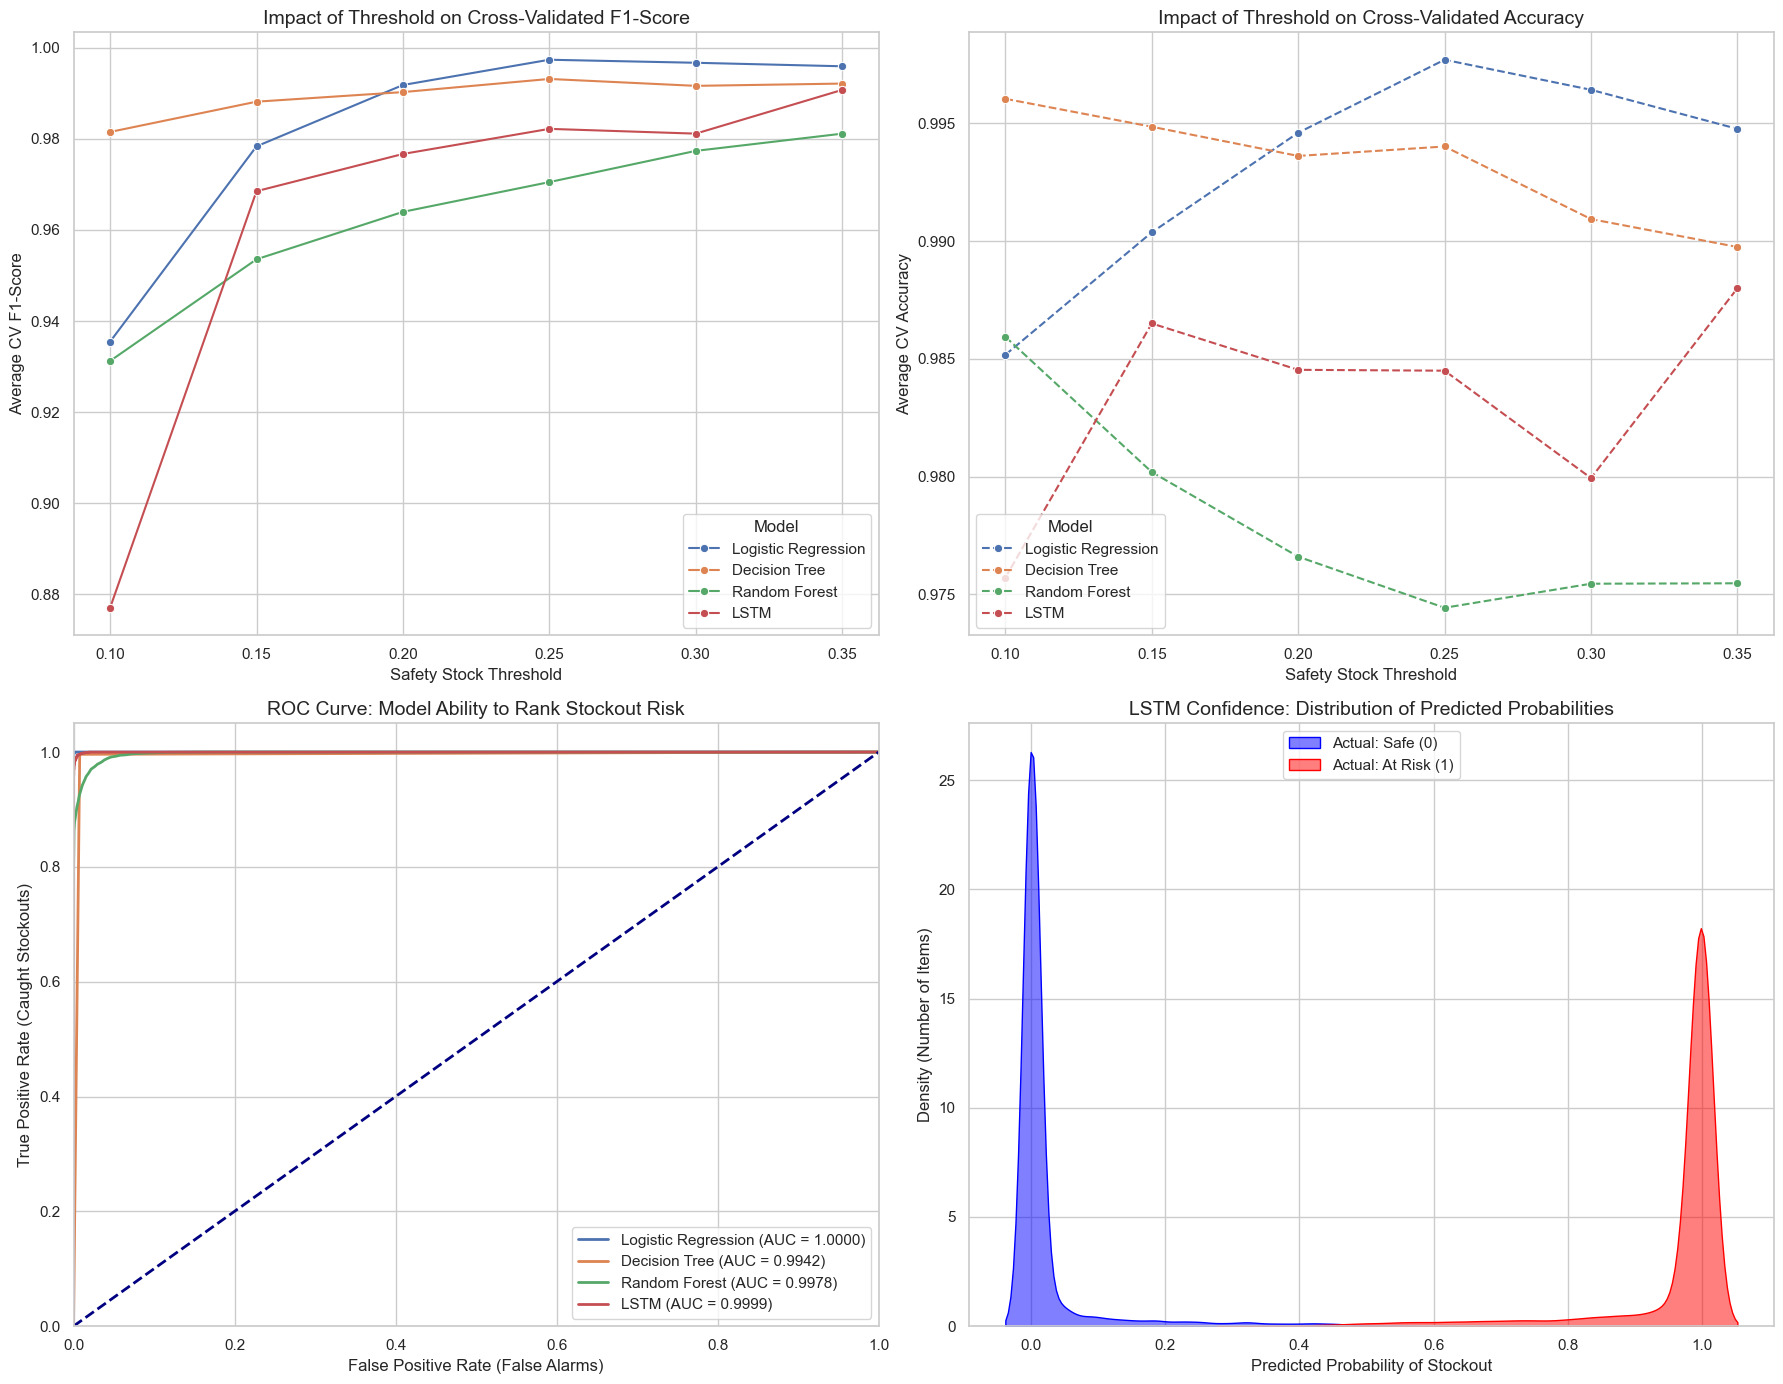


Grid visuals successfully generated and saved!
=== Final Model Performance (80/20 Time Split, α=0.25) ===


,Accuracy,F1-Score,Precision,Recall,AUC
Model,,,,,
Logistic Regression,0.9974,0.9970,0.9940,1.0000,1.0000
Decision Tree,0.9939,0.9928,0.9897,0.9960,0.9942
Random Forest,0.9741,0.9698,0.9650,0.9746,0.9978
LSTM,0.9940,0.9930,0.9949,0.9911,0.9999


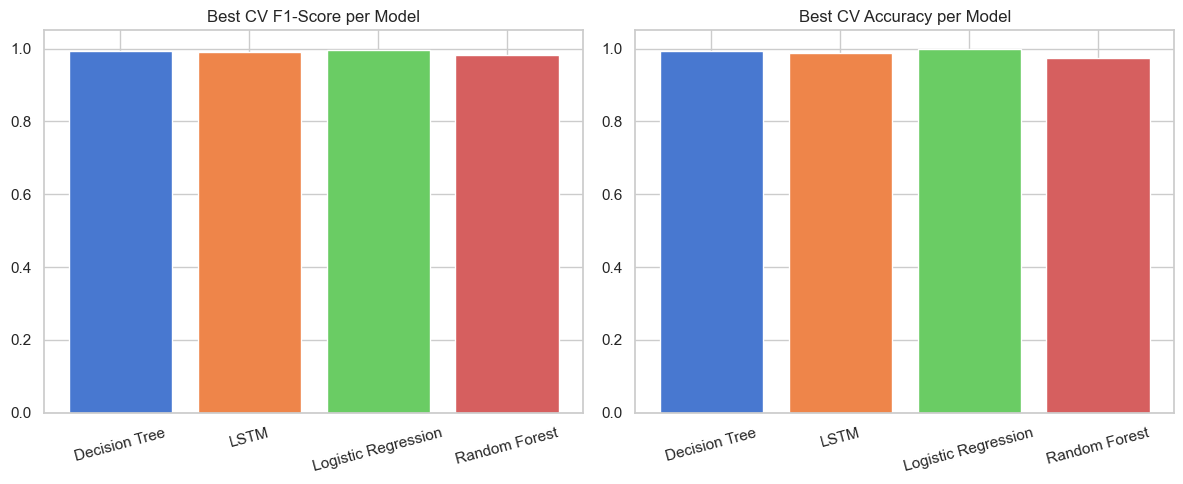

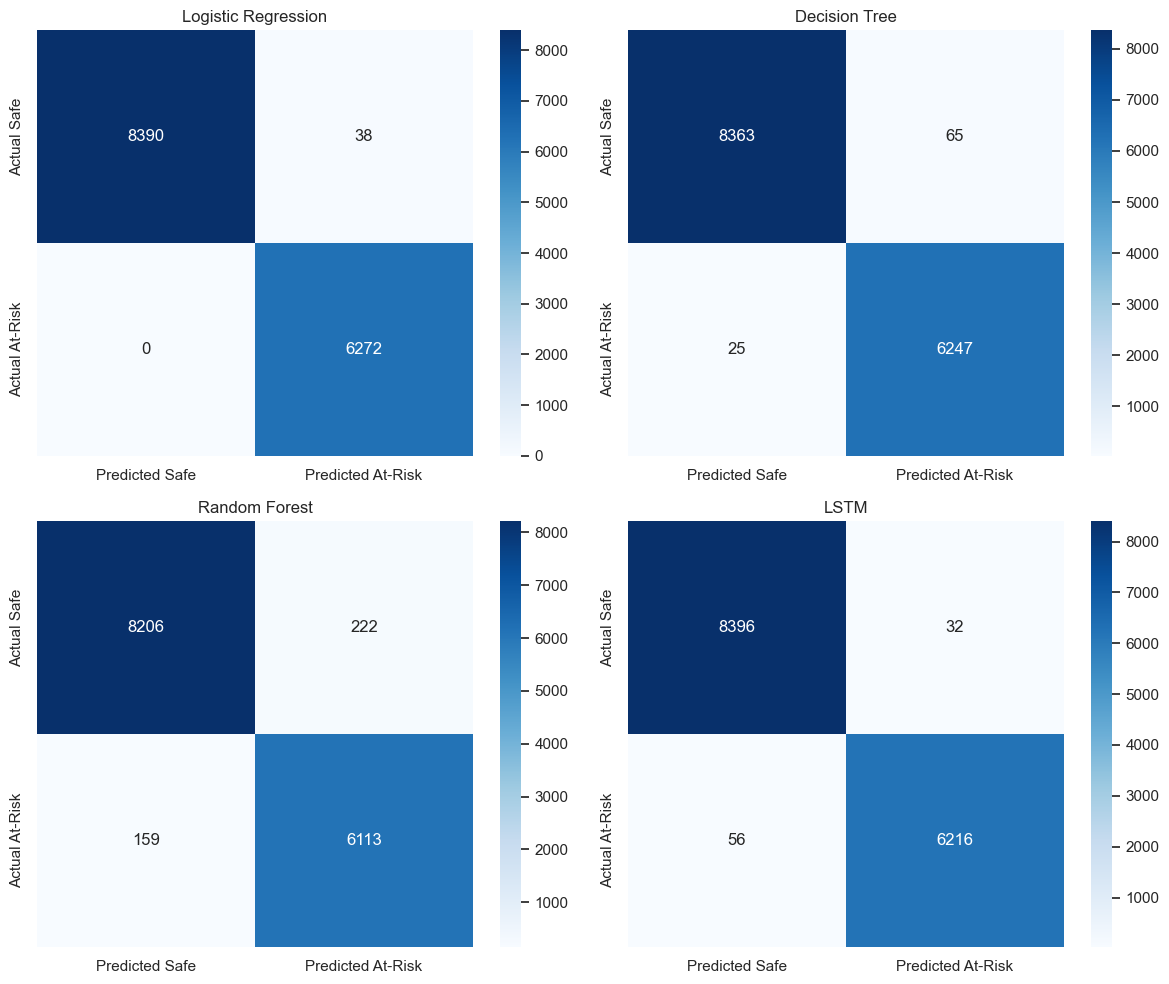

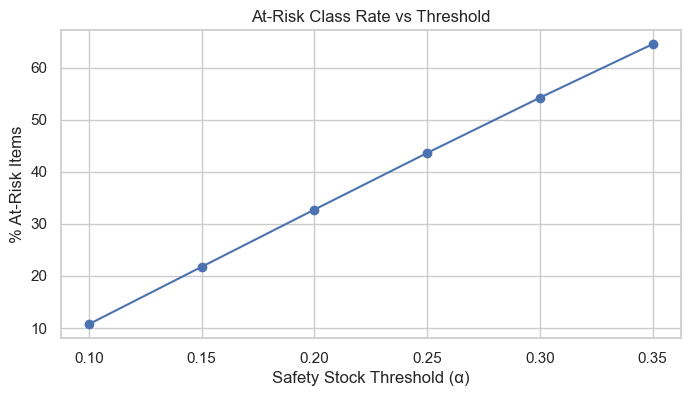

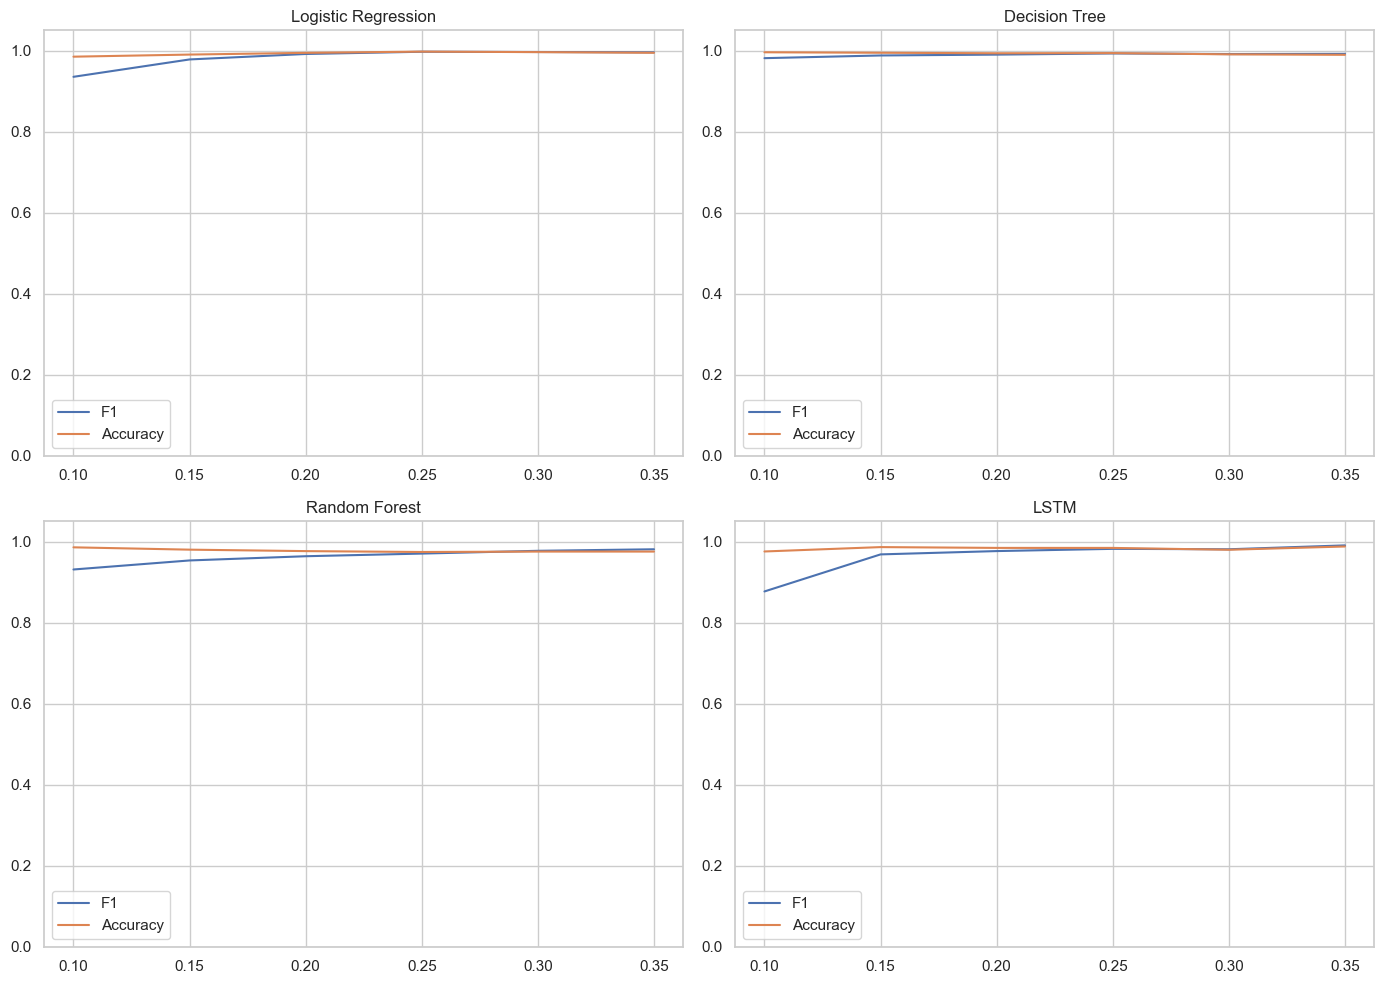

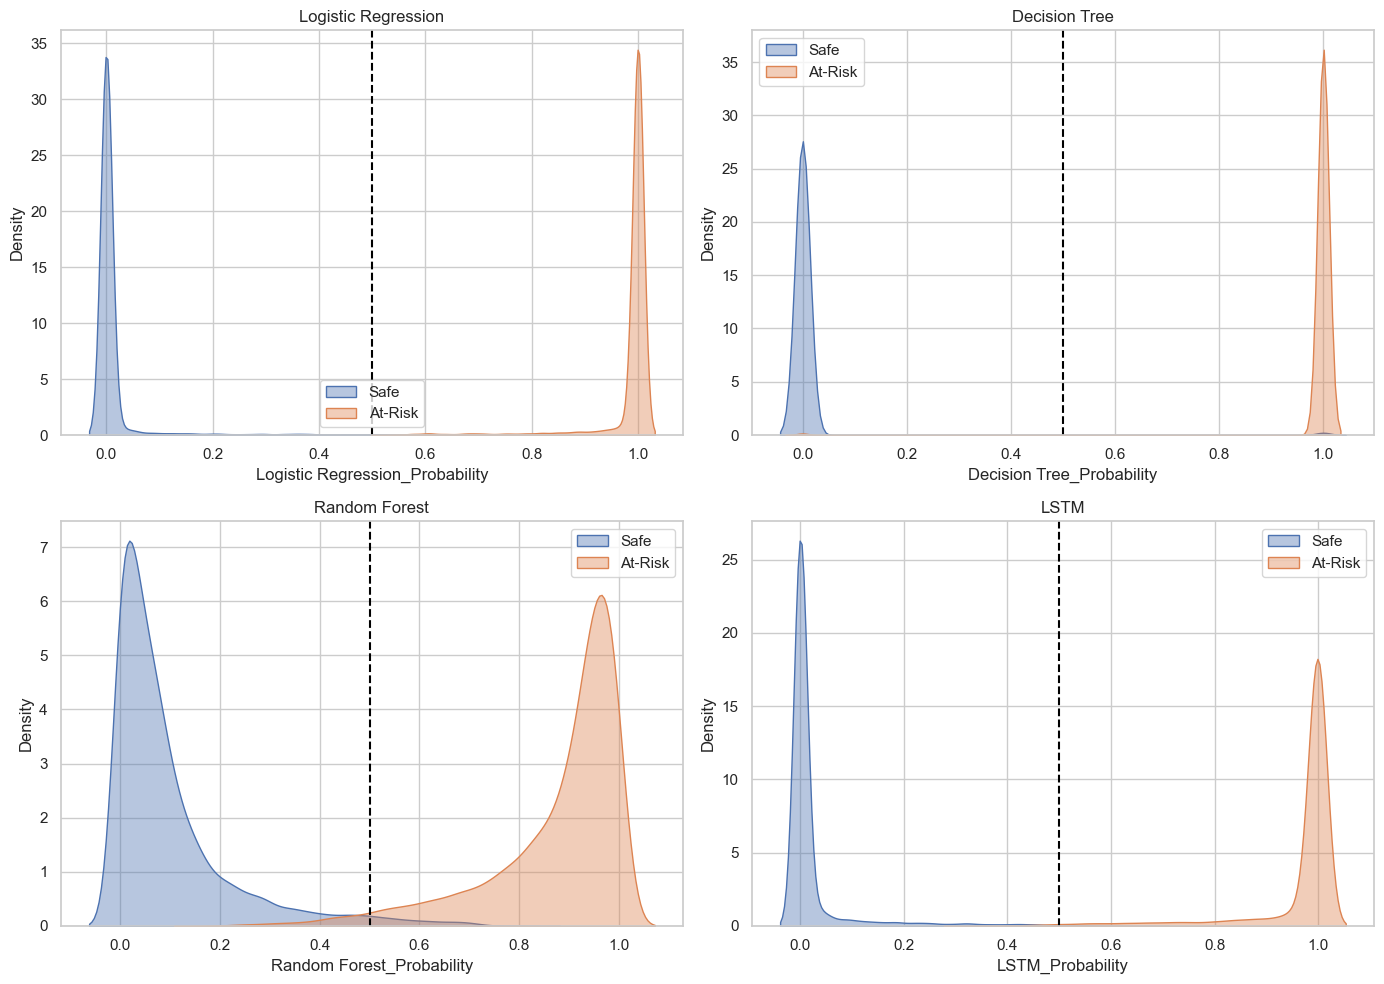

In [4]:
# ---------------------------------------------------------
# Generate Visuals (2x2 Grid)
# ---------------------------------------------------------

sns.set_theme(style="whitegrid")

# Make sure the dataframes are loaded
df_sens = pd.read_csv("cv_threshold_sensitivity.csv")
df_probs = pd.read_csv("stockout_probabilities.csv")
y_true = df_probs["Actual_Risk_Label"]

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 14))

# ---------------------------------------------------------
# Plot 1 (Top-Left): F1-Score vs Threshold
# ---------------------------------------------------------
sns.lineplot(data=df_sens, x="Threshold", y="F1_Score", hue="Model", marker="o", ax=axes[0, 0])
axes[0, 0].set_title("Impact of Threshold on Cross-Validated F1-Score", fontsize=14)
axes[0, 0].set_xlabel("Safety Stock Threshold", fontsize=12)
axes[0, 0].set_ylabel("Average CV F1-Score", fontsize=12)
axes[0, 0].legend(title="Model", loc="best")

# ---------------------------------------------------------
# Plot 2 (Top-Right): Accuracy vs Threshold
# ---------------------------------------------------------
sns.lineplot(data=df_sens, x="Threshold", y="Accuracy", hue="Model", marker="o", linestyle="--", ax=axes[0, 1])
axes[0, 1].set_title("Impact of Threshold on Cross-Validated Accuracy", fontsize=14)
axes[0, 1].set_xlabel("Safety Stock Threshold", fontsize=12)
axes[0, 1].set_ylabel("Average CV Accuracy", fontsize=12)
axes[0, 1].legend(title="Model", loc="best")

# ---------------------------------------------------------
# Plot 3 (Bottom-Left): ROC Curve for All Models
# ---------------------------------------------------------
models_to_plot = ["Logistic Regression", "Decision Tree", "Random Forest", "LSTM"]

for model_name in models_to_plot:
    col_name = f"{model_name}_Probability"
    if col_name in df_probs.columns:
        # Calculate False Positive Rate, True Positive Rate, and the AUC Score
        fpr, tpr, thresholds = roc_curve(y_true, df_probs[col_name])
        roc_auc = auc(fpr, tpr)
        
        # Plot the curve for this specific model onto the bottom-left axis
        axes[1, 0].plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.4f})')

# Plot the "Random Guessing" diagonal line
axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1, 0].set_xlim([0.0, 1.0])
axes[1, 0].set_ylim([0.0, 1.05])
axes[1, 0].set_xlabel('False Positive Rate (False Alarms)', fontsize=12)
axes[1, 0].set_ylabel('True Positive Rate (Caught Stockouts)', fontsize=12)
axes[1, 0].set_title('ROC Curve: Model Ability to Rank Stockout Risk', fontsize=14)
axes[1, 0].legend(loc="lower right")

# ---------------------------------------------------------
# Plot 4 (Bottom-Right): Probability Distribution for LSTM
# ---------------------------------------------------------
# Density for items that were ACTUALLY SAFE (Label 0)
sns.kdeplot(
    data=df_probs[df_probs["Actual_Risk_Label"] == 0], 
    x="LSTM_Probability", fill=True, color="blue", alpha=0.5, label="Actual: Safe (0)", ax=axes[1, 1]
)

# Density for items that were ACTUALLY AT RISK (Label 1)
sns.kdeplot(
    data=df_probs[df_probs["Actual_Risk_Label"] == 1], 
    x="LSTM_Probability", fill=True, color="red", alpha=0.5, label="Actual: At Risk (1)", ax=axes[1, 1]
)

axes[1, 1].set_title("LSTM Confidence: Distribution of Predicted Probabilities", fontsize=14)
axes[1, 1].set_xlabel("Predicted Probability of Stockout", fontsize=12)
axes[1, 1].set_ylabel("Density (Number of Items)", fontsize=12)
axes[1, 1].legend(loc="upper center")

# ---------------------------------------------------------
# Final Formatting and Display
# ---------------------------------------------------------
plt.tight_layout()
plt.savefig("combined_model_visuals.png", dpi=300) # Saves the entire 2x2 grid as one high-res image
plt.show()

print("\nGrid visuals successfully generated and saved!")

df_sens  = pd.read_csv("cv_threshold_sensitivity.csv")
df_probs = pd.read_csv("stockout_probabilities.csv")
y_true   = df_probs["Actual_Risk_Label"]

models_to_plot = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "LSTM"
]

# Model Performance Summary Table
summary_rows = []

for model_name in models_to_plot:
    col = f"{model_name}_Probability"
    if col in df_probs.columns:
        y_pred  = (df_probs[col] >= 0.5).astype(int)
        y_score = df_probs[col]
        fpr, tpr, _ = roc_curve(y_true, y_score)

        summary_rows.append({
            "Model":     model_name,
            "Accuracy":  round(accuracy_score(y_true, y_pred),  4),
            "F1-Score":  round(f1_score(y_true, y_pred),        4),
            "Precision": round(precision_score(y_true, y_pred), 4),
            "Recall":    round(recall_score(y_true, y_pred),    4),
            "AUC":       round(auc(fpr, tpr),                   4),
        })

df_summary = pd.DataFrame(summary_rows).set_index("Model")

print("=== Final Model Performance (80/20 Time Split, α=0.25) ===")
display(df_summary)

df_summary.to_csv("model_performance_summary.csv")

# Best Threshold Comparison
best_rows = (
    df_sens.sort_values("F1_Score", ascending=False)
           .groupby("Model")
           .first()
           .reset_index()[["Model", "Threshold", "F1_Score", "Accuracy"]]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
palette = sns.color_palette("muted", len(best_rows))

axes[0].bar(best_rows["Model"], best_rows["F1_Score"], color=palette)
axes[0].set_title("Best CV F1-Score per Model")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(best_rows["Model"], best_rows["Accuracy"], color=palette)
axes[1].set_title("Best CV Accuracy per Model")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, model_name in enumerate(models_to_plot):
    col = f"{model_name}_Probability"
    y_pred = (df_probs[col] >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Predicted Safe", "Predicted At-Risk"],
        yticklabels=["Actual Safe", "Actual At-Risk"],
        ax=axes[idx]
    )

    axes[idx].set_title(model_name)

plt.tight_layout()
plt.show()

# At-Risk Rate vs Threshold
at_risk_by_threshold = (
    df_sens.groupby("Threshold")["At_Risk_Rate_Test"]
           .mean()
           .reset_index()
)

plt.figure(figsize=(8, 4))
plt.plot(
    at_risk_by_threshold["Threshold"],
    at_risk_by_threshold["At_Risk_Rate_Test"] * 100,
    marker="o"
)

plt.title("At-Risk Class Rate vs Threshold")
plt.xlabel("Safety Stock Threshold (α)")
plt.ylabel("% At-Risk Items")
plt.grid(True)
plt.show()

# F1 & Accuracy vs Threshold
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, model_name in enumerate(models_to_plot):
    subset = df_sens[df_sens["Model"] == model_name]

    axes[idx].plot(subset["Threshold"], subset["F1_Score"], label="F1")
    axes[idx].plot(subset["Threshold"], subset["Accuracy"], label="Accuracy")

    axes[idx].set_title(model_name)
    axes[idx].set_ylim(0, 1.05)
    axes[idx].legend()

plt.tight_layout()
plt.show()

# Probability Distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, model_name in enumerate(models_to_plot):
    col = f"{model_name}_Probability"

    for label_val, label_name in [(0, "Safe"), (1, "At-Risk")]:
        subset = df_probs[df_probs["Actual_Risk_Label"] == label_val]

        sns.kdeplot(
            data=subset,
            x=col,
            fill=True,
            alpha=0.4,
            label=label_name,
            ax=axes[idx]
        )

    axes[idx].axvline(0.5, linestyle="--", color="black")
    axes[idx].set_title(model_name)
    axes[idx].legend()

plt.tight_layout()
plt.show()